# Redes Neuronales Densas — Modelos de Forecasting

Objetivo: Entrenar modelos de redes neuronales con capas densas para predecir el promedio del log-return de cierre futuro de 23 activos del S&P 500, a través de 16 combinaciones de ventanas temporales de entrada y salida

Métrica: MAE

In [2]:
import os
import sys
sys.path.append('..')
os.chdir('..')

## 1. Importar y configuración

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, History

# Infraestructura compartida del proyecto
from src.data_pipeline import load_data, get_train_test
from src.evaluation import compute_mae, save_results, count_parameters
from src.plotting import plot_training_curves
from config import INPUT_WINDOWS, OUTPUT_WINDOWS, FIGURES_DIR, MODELS_DIR

import os
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

# Reproducibilidad
tf.random.set_seed(42)
np.random.seed(42)

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.21.0


## 2. Carga de datos

In [4]:
returns = load_data()
print(f"\nShape: {returns.shape}")
print(f"Columnas: {list(returns.columns)}")
returns.head()

[*********************100%***********************]  23 of 23 completed

Datos cargados: 16195 días, 23 activos
Rango: 1962-01-03 → 2026-05-08

Shape: (16195, 23)
Columnas: ['AEP', 'BA', 'CAT', 'CNP', 'CVX', 'DIS', 'DTE', 'ED', 'GD', 'GE', 'HON', 'HPQ', 'IBM', 'IP', 'JNJ', 'KO', 'KR', 'MMM', 'MO', 'MRK', 'MSI', 'PG', 'XOM']


Ticker,AEP,BA,CAT,CNP,CVX,DIS,DTE,ED,GD,GE,...,IP,JNJ,KO,KR,MMM,MO,MRK,MSI,PG,XOM
Date,,,,,,,,,,,,,,,,,,,,,
1962-01-03,-0.001823,0.019803,0.009693,-0.009820,-0.002260,0.013332,-0.008265,0.000000,0.032926,-0.010085,...,-0.013745,-0.015669,-0.022532,0.020791,0.007491,-0.018519,-0.042803,-0.002912,-0.010989,0.014742
1962-01-04,-0.014707,-0.009851,0.025398,0.000000,-0.009091,0.000000,-0.008333,-0.003092,0.004040,-0.011893,...,-0.003467,-0.010578,0.007570,-0.004123,0.000000,0.006985,-0.010255,-0.008784,-0.016714,0.002437
1962-01-05,-0.022473,-0.020002,0.009360,-0.024419,-0.025435,0.003308,-0.021143,-0.021909,0.004023,-0.025976,...,0.010363,-0.016090,-0.022875,-0.025107,-0.026466,0.011534,-0.034463,-0.005900,-0.007047,-0.022142
1962-01-08,-0.007605,0.002522,0.006192,-0.011300,-0.004694,-0.003308,0.002135,0.004735,0.015937,-0.001756,...,-0.020835,-0.016348,-0.010334,-0.004247,-0.005764,-0.006905,0.003045,-0.017912,-0.027242,-0.002491
1962-01-09,-0.007662,0.002516,0.009217,0.000000,0.014019,0.019676,0.002130,-0.001575,0.003945,0.005259,...,-0.014134,0.010930,0.018016,-0.021505,0.000000,-0.018647,0.004550,-0.024391,-0.001455,-0.002496


## 3. Entranamiento de modelos

### 3.1 Preparación de datos

In [115]:
# Configuración de ventanas para este primer modelo
INPUT_W = 30
OUTPUT_W = 5

# Generar datos con ventanas y split (90% train / 10% test, cronológico)
X_train, X_test, y_train, y_test = get_train_test(returns, INPUT_W, OUTPUT_W)

print(f"\nInput shape:  X_train {X_train.shape} → (muestras, timesteps={INPUT_W}, activos=23)")
print(f"Output shape: y_train {y_train.shape} → (muestras, activos=23)")

Ventana entrada=30, salida=5
  X_train: (14544, 30, 23) | y_train: (14544, 23)
  X_test:  (1617, 30, 23)  | y_test:  (1617, 23)

Input shape:  X_train (14544, 30, 23) → (muestras, timesteps=30, activos=23)
Output shape: y_train (14544, 23) → (muestras, activos=23)


In [116]:
num_samples_train = X_train.shape[0]

# Flatten X_train to (num_samples, input_window_size * num_features)
X_train_flat = X_train.reshape(num_samples_train, -1)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_flat)

print(f"Shape of X_train_flat: {X_train_flat.shape}")

X_train_scaled

Shape of X_train_flat: (14544, 690)


array([[-0.16520215,  0.95715424,  0.5049287 , ..., -0.01627846,
        -0.25618746, -0.53862939],
       [-1.16622143, -0.51484952,  1.35614013, ...,  0.88765023,
        -0.03108693,  0.81132171],
       [-1.76962669, -1.01870198,  0.48685636, ...,  0.61790584,
         0.1940136 ,  0.1358108 ],
       ...,
       [ 0.24461898,  0.08814195,  0.65076037, ...,  0.77016681,
        -0.31547829, -0.78215006],
       [-0.24973264, -0.55287388,  1.43468278, ...,  0.07590266,
         0.49450014,  0.19430555],
       [-0.25039303,  0.49590076,  2.44510371, ..., -0.35008288,
        -1.21439255,  1.70939191]], shape=(14544, 690))

### 3.2 Modelo sencillo 

In [135]:
from keras.models import Sequential
from keras.layers import Input, Dense
from keras.optimizers import Adam


def crear_modelo_denso(num_caracteristicas, num_activos=23):
    """Crea una arquitectura MLP (Capa Densa) limpia"""
    model = Sequential([
        Input(shape=(num_caracteristicas,)),
        Dense(50, activation='relu'),
        Dense(num_activos, activation='linear') # Salida
    ])
    
    model.compile(optimizer=Adam(learning_rate=0.0005), 
                  loss='mse', 
                  metrics=['mae'])
    return model


In [136]:
from config import INPUT_WINDOWS, OUTPUT_WINDOWS
from src.data_pipeline import get_train_test

# Diccionario para guardar el historial de cada combinación
historias_entrenamiento = {}

for iw in INPUT_WINDOWS:
    for ow in OUTPUT_WINDOWS:
        print(f"\nEntrenando -> Entrada: {iw} días | Salida: {ow} días")
        
        # 1. Obtener datos
        X_train, X_test, y_train, y_test = get_train_test(returns, input_window=iw, output_window=ow)
        
        # 2. Aplanar (Flatten) porque es un modelo Denso
        X_train_flat = X_train.reshape(X_train.shape[0], -1)
        X_test_flat = X_test.reshape(X_test.shape[0], -1)
        
        # 3. Crear modelo fresco
        num_caracteristicas = X_train_flat.shape[1]
        model = crear_modelo_denso(num_caracteristicas)
        
        # 5. Entrenar y guardar
        hist = model.fit(
            X_train_flat, y_train,
            epochs=50,             # Ajusta esto según necesites
            validation_split= 0.1,
            shuffle=True
        )
        
        # Guardamos la curva con una clave identificativa, ej: "In:30 Out:5"
        llave = f"In:{iw} Out:{ow}"
        historias_entrenamiento[llave] = hist.history



Entrenando -> Entrada: 5 días | Salida: 1 días
Ventana entrada=5, salida=1
  X_train: (14571, 5, 23) | y_train: (14571, 23)
  X_test:  (1619, 5, 23)  | y_test:  (1619, 23)
Epoch 1/50
410/410 ━━━━━━━━━━━━━━━━━━━━ 1s 904us/step - loss: 3.3235e-04 - mae: 0.0125 - val_loss: 1.7116e-04 - val_mae: 0.0091
Epoch 2/50
410/410 ━━━━━━━━━━━━━━━━━━━━ 0s 634us/step - loss: 3.0317e-04 - mae: 0.0119 - val_loss: 1.7085e-04 - val_mae: 0.0091
Epoch 3/50
410/410 ━━━━━━━━━━━━━━━━━━━━ 0s 690us/step - loss: 3.0057e-04 - mae: 0.0119 - val_loss: 1.7080e-04 - val_mae: 0.0090
Epoch 4/50
410/410 ━━━━━━━━━━━━━━━━━━━━ 0s 683us/step - loss: 2.9901e-04 - mae: 0.0119 - val_loss: 1.7077e-04 - val_mae: 0.0090
Epoch 5/50
410/410 ━━━━━━━━━━━━━━━━━━━━ 0s 805us/step - loss: 2.9760e-04 - mae: 0.0119 - val_loss: 1.7078e-04 - val_mae: 0.0090
Epoch 6/50
410/410 ━━━━━━━━━━━━━━━━━━━━ 0s 676us/step - loss: 2.9635e-04 - mae: 0.0119 - val_loss: 1.7077e-04 - val_mae: 0.0090
Epoch 7/50
410/410 ━━━━━━━━━━━━━━━━━━━━ 0s 717us/step - los

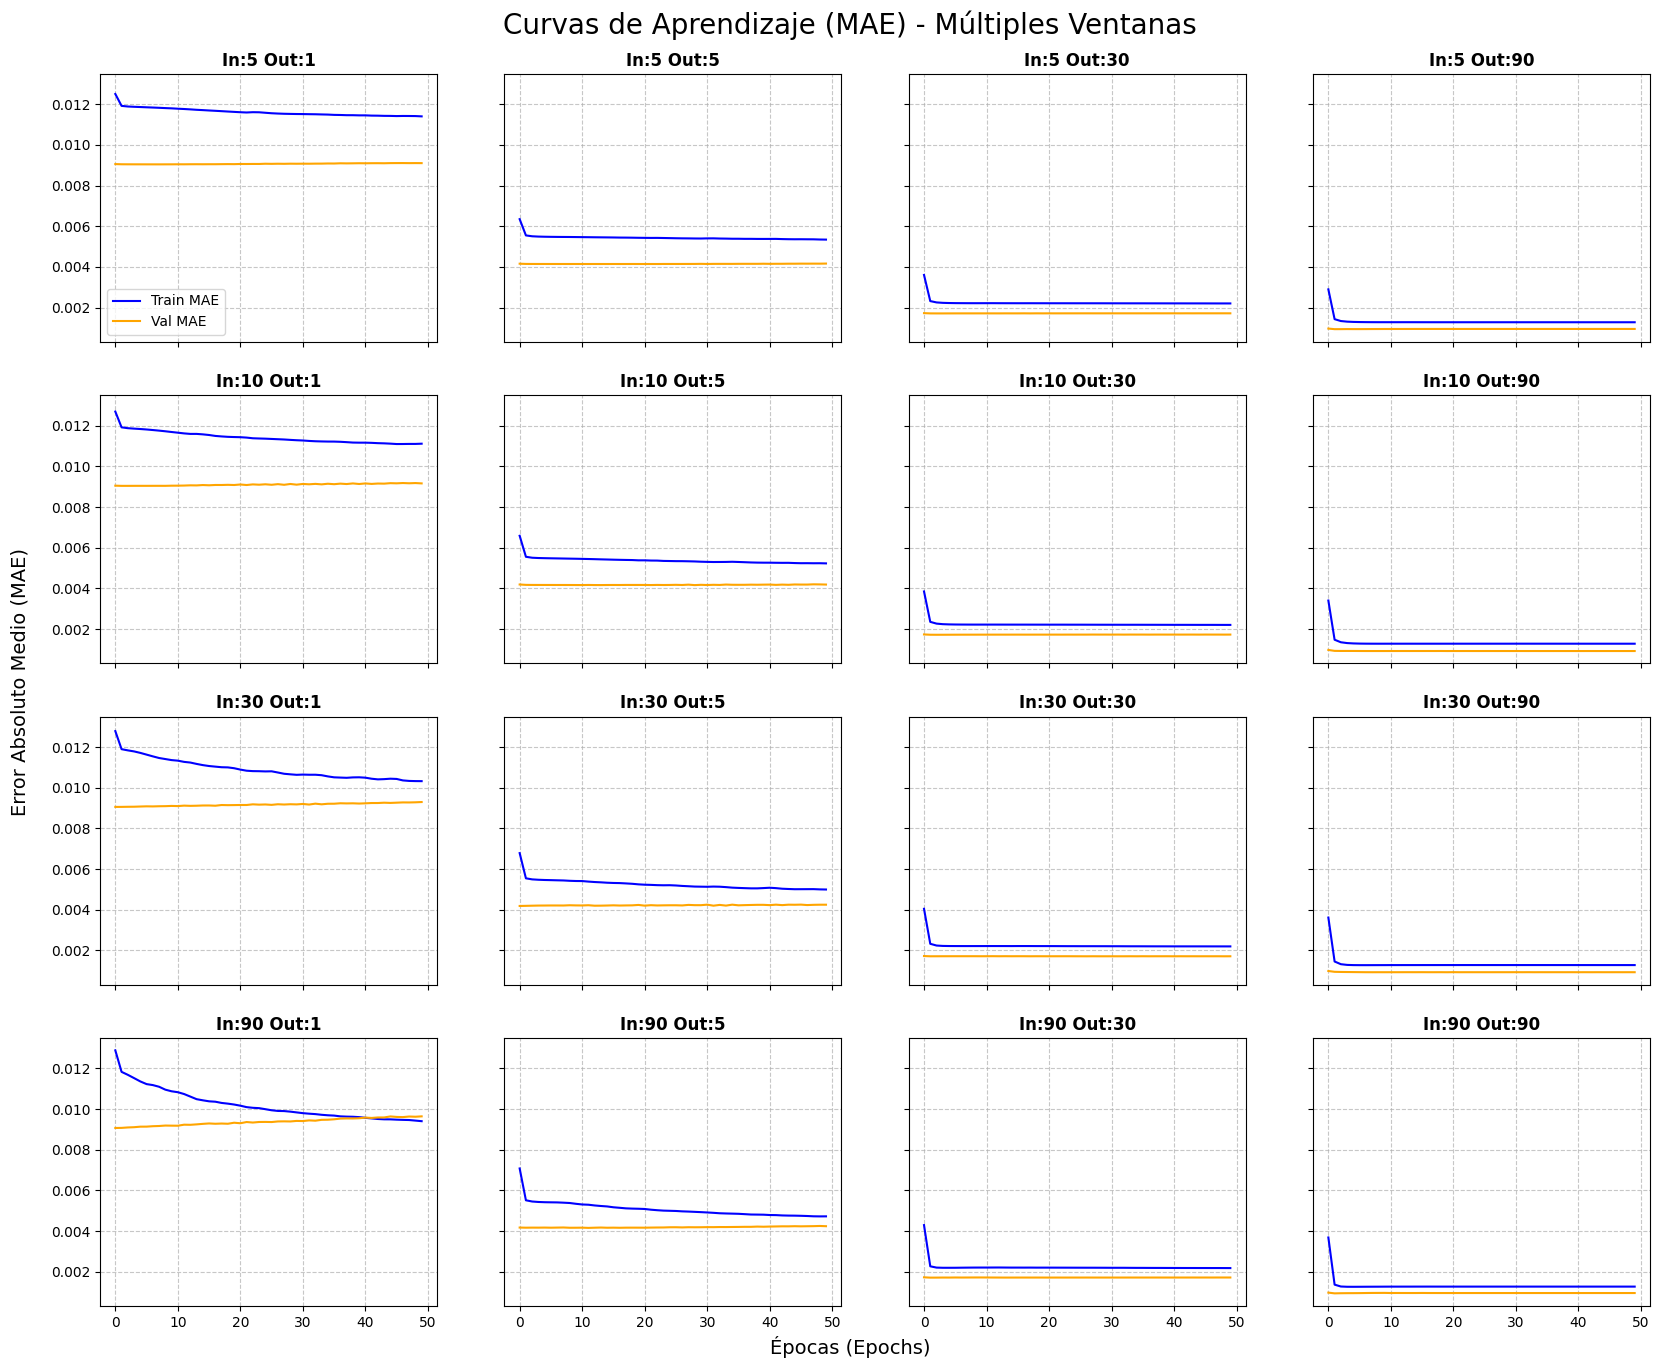

In [137]:
# Crear una matriz de gráficas 4x4
fig, axes = plt.subplots(nrows=len(INPUT_WINDOWS), 
                         ncols=len(OUTPUT_WINDOWS), 
                         figsize=(20, 16), 
                         sharex=True, 
                         sharey=True) # sharey=True para poder comparar las escalas visualmente

# Título global
fig.suptitle("Curvas de Aprendizaje (MAE) - Múltiples Ventanas", fontsize=20, y=0.92)

for i, iw in enumerate(INPUT_WINDOWS):
    for j, ow in enumerate(OUTPUT_WINDOWS):
        ax = axes[i, j]
        llave = f"In:{iw} Out:{ow}"
        historia = historias_entrenamiento[llave]
        
        # Dibujar líneas de Entrenamiento y Validación
        ax.plot(historia['mae'], label='Train MAE', color='blue')
        ax.plot(historia['val_mae'], label='Val MAE', color='orange')
        
        # Títulos y estilos para cada subgráfica
        ax.set_title(llave, fontsize=12, fontweight='bold')
        ax.grid(True, linestyle='--', alpha=0.7)
        
        # Poner leyendas solo en la primera para no recargar visualmente
        if i == 0 and j == 0:
            ax.legend()

# Etiquetas de los ejes principales
fig.text(0.5, 0.08, 'Épocas (Epochs)', ha='center', fontsize=14)
fig.text(0.08, 0.5, 'Error Absoluto Medio (MAE)', va='center', rotation='vertical', fontsize=14)

plt.show()


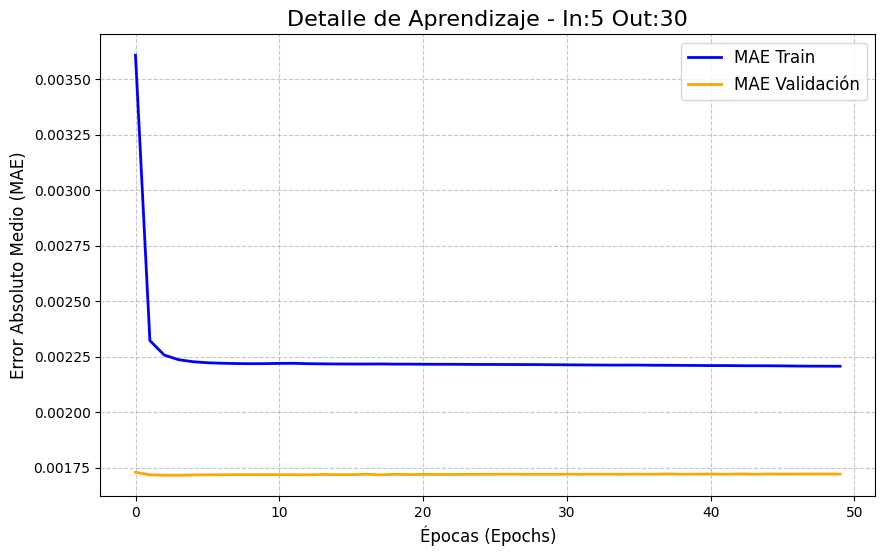

In [142]:
# Elige la combinación que quieras ver en detalle
llave_detalle = "In:5 Out:30"

# Extraemos solo su historial
historia_individual = historias_entrenamiento[llave_detalle]

# Dibujamos la gráfica en tamaño grande
plt.figure(figsize=(10, 6))

plt.plot(historia_individual['mae'], label='MAE Train', color='blue', linewidth=2)
plt.plot(historia_individual['val_mae'], label='MAE Validación', color='orange', linewidth=2)

plt.title(f'Detalle de Aprendizaje - {llave_detalle}', fontsize=16)
plt.xlabel('Épocas (Epochs)', fontsize=12)
plt.ylabel('Error Absoluto Medio (MAE)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# Opcional: limitar el eje Y si el primer pico distorsiona mucho la gráfica
# plt.ylim(0, 0.05) 

plt.show()
